In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 - 3*x + 1

def df(x):
    return 3*x**2 - 3

def ddf(x):
    return 6*x

def gradient_descent(x0, alpha=0.01, eps=1e-6, max_iter=10000):
    x = float(x0)
    iterates = [x]

    for k in range(max_iter):
        grad = df(x)
        if abs(grad) < eps:
            return x, k + 1, np.array(iterates)

        x = x - alpha * grad
        if abs(x) > 1e6:    # Divergence safeguard
            print("GD diverged due to large step size.")
            return x, k + 1, np.array(iterates)

        iterates.append(x)

    return x, max_iter, np.array(iterates)

def newtons_method(x0, eps=1e-6, max_iter=10000):
    x = float(x0)
    iterates = [x]

    for k in range(max_iter):
        grad = df(x)
        if abs(grad) < eps:
            return x, k + 1, np.array(iterates)

        hess = ddf(x)
        if abs(hess) < 1e-12:
            print("Newton failed: f''(x) ≈ 0")
            return x, k + 1, np.array(iterates)

        x = x - grad / hess
        iterates.append(x)

    return x, max_iter, np.array(iterates)

GD diverged due to large step size.

Initial point x0 = 2.0
GD:
  Iterations = 247
  x*         = 1.000000
  f(x*)      = -1.000000
  f''(x*)    = 6.000001
  Nature     = Local Minimizer
Newton:
  Iterations = 5
  x*         = 1.000000
  f(x*)      = -1.000000
  f''(x*)    = 6.000000
  Nature     = Local Minimizer

Initial point x0 = -2.0
GD:
  Iterations = 25
  x*         = -161340231.202531
  f(x*)      = -4199794349148617660432384.000000
  f''(x*)    = -968041387.215185
  Nature     = Local Maximizer
Newton:
  Iterations = 5
  x*         = -1.000000
  f(x*)      = 3.000000
  f''(x*)    = -6.000000
  Nature     = Local Maximizer


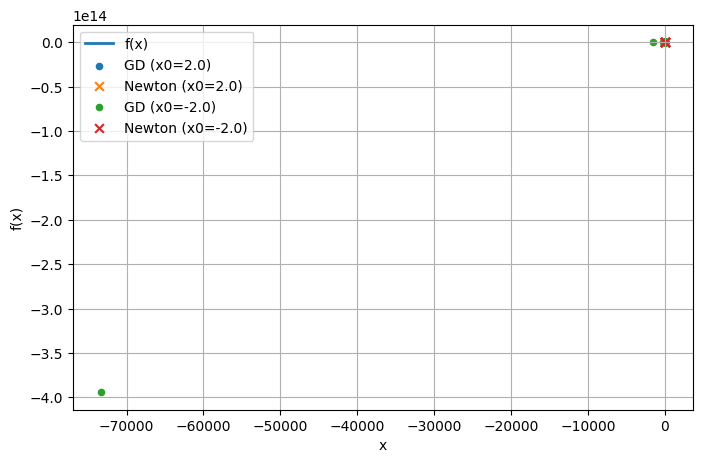

In [ ]:
eps = 1e-6
alpha = 0.01
initial_points = [2.0, -2.0]

results = {}

for x0 in initial_points:
    gd_x, gd_it, gd_path = gradient_descent(x0, alpha, eps)
    nt_x, nt_it, nt_path = newtons_method(x0, eps)

    results[x0] = {
        "GD": (gd_x, gd_it, gd_path),
        "Newton": (nt_x, nt_it, nt_path)
    }

for x0 in initial_points:
    print(f"\nInitial point x0 = {x0}")

    for method in ["GD", "Newton"]:
        x_star, iters, path = results[x0][method]
        nature = "Local Minimizer" if ddf(x_star) > 0 else "Local Maximizer"

        print(f"{method}:")
        print(f"  Iterations = {iters}")
        print(f"  x*         = {x_star:.6f}")
        print(f"  f(x*)      = {f(x_star):.6f}")
        print(f"  f''(x*)    = {ddf(x_star):.6f}")
        print(f"  Nature     = {nature}")

x_plot = np.linspace(-3, 3, 400)
plt.figure(figsize=(8, 5))
plt.plot(x_plot, f(x_plot), label="f(x)", linewidth=2)

for x0 in initial_points:
    gd_path = results[x0]["GD"][2]
    nt_path = results[x0]["Newton"][2]
    plt.scatter(gd_path, f(gd_path), s=20, label=f"GD (x0={x0})")
    plt.scatter(nt_path, f(nt_path), s=40, marker="x", label=f"Newton (x0={x0})")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

During experimentation it was observed that:

- Newton’s method converges in very few iterations due to quadratic convergence near critical points.
- Gradient Descent is highly sensitive to step size - when it's too large, it leads to divergence and overflow.
